In [1]:
from __future__ import print_function, division

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

plt.style.use('seaborn-v0_8')

(np.float64(-2.7292712056271964),
 np.float64(2.5702744393352615),
 np.float64(-0.9326181575178751),
 np.float64(1.004413830229183))

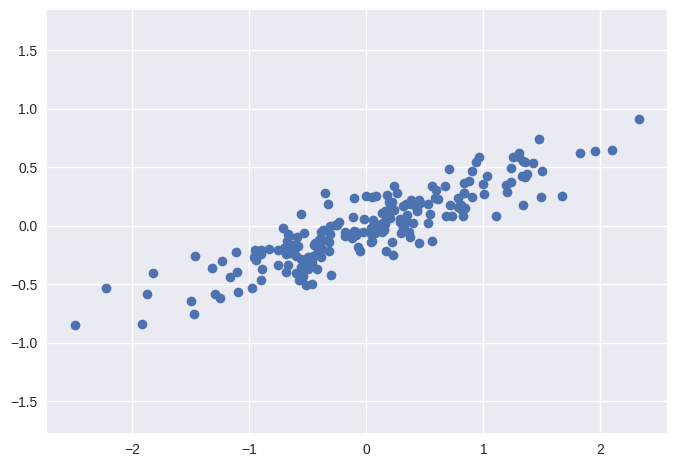

In [2]:
np.random.seed(1)

X = np.dot(np.random.random(size=(2, 2)),
           np.random.normal(size=(2, 200))).T

plt.plot(X[:, 0], X[:, 1], 'o')
plt.axis('equal')

In [3]:
pca = PCA(n_components=2)
pca.fit(X)

PCA(n_components=2)

In [4]:
print(pca.explained_variance_)
print(pca.components_)

[0.7625315 0.0184779]
[[ 0.94446029  0.32862557]
 [-0.32862557  0.94446029]]


(np.float64(-2.736511634479499),
 np.float64(2.7223234452336147),
 np.float64(-0.9326181575178751),
 np.float64(1.004413830229183))

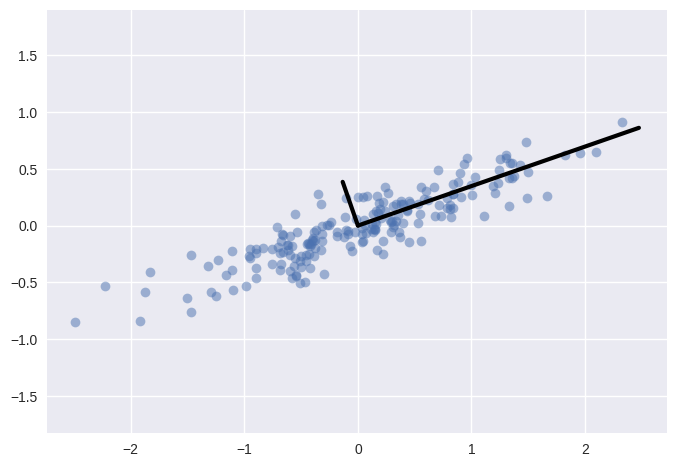

In [5]:
plt.plot(X[:, 0], X[:, 1], 'o', alpha=0.5)

for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    plt.plot([0, v[0]], [0, v[1]], '-k', lw=3)

plt.axis('equal')

In [6]:
clf = PCA(0.95)

In [7]:
X_trans = clf.fit_transform(X)

print(X.shape)
print(X_trans.shape)

(200, 2)
(200, 1)


(np.float64(-2.731158226766438),
 np.float64(2.609901883259332),
 np.float64(-0.967276570638932),
 np.float64(1.006064230853995))

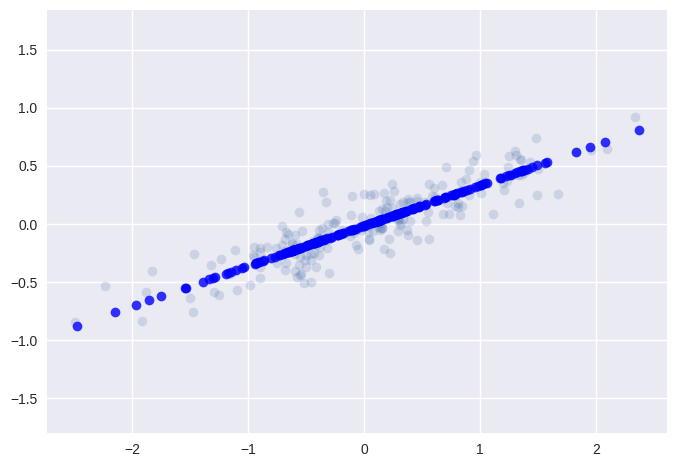

In [8]:
X_reconstructed = clf.inverse_transform(X_trans)

plt.plot(X[:, 0], X[:, 1], 'o', alpha=0.2)
plt.plot(X_reconstructed[:, 0], X_reconstructed[:, 1], 'ob', alpha=0.8)

plt.axis('equal')

In [9]:
digits = load_digits()

X = digits.data
y = digits.target

In [10]:
pca = PCA(n_components=2)

Xproj = pca.fit_transform(X)

print(X.shape)
print(Xproj.shape)

(1797, 64)
(1797, 2)


/tmp/ipykernel_943/497117038.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('nipy_spectral', 10))


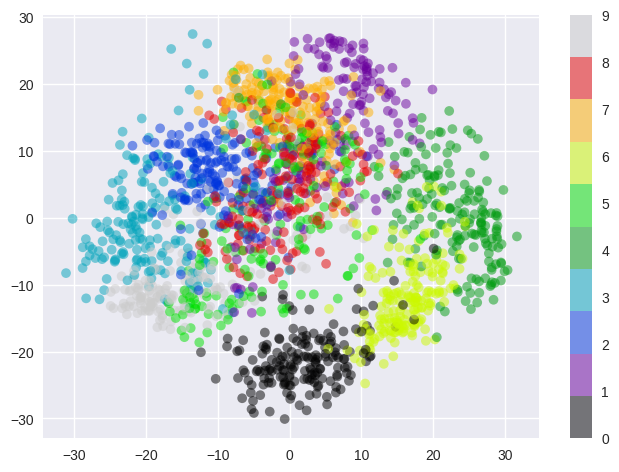

In [11]:
plt.scatter(Xproj[:, 0], Xproj[:, 1],
            c=y,
            edgecolor='none',
            alpha=0.5,
            cmap=plt.cm.get_cmap('nipy_spectral', 10))

plt.colorbar()

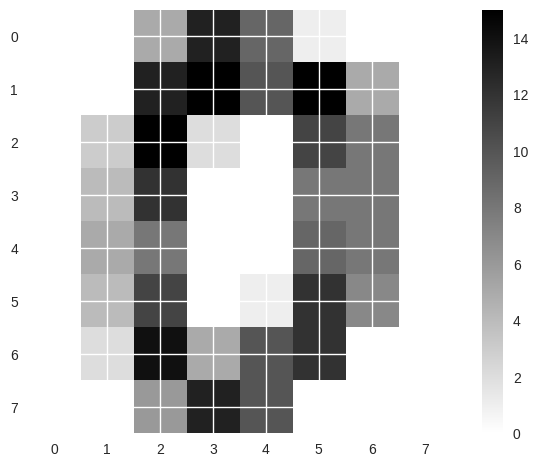

In [12]:
plt.imshow(digits.images[0], cmap='binary')
plt.colorbar()
plt.show()

Text(0, 0.5, 'cumulative explained variance')

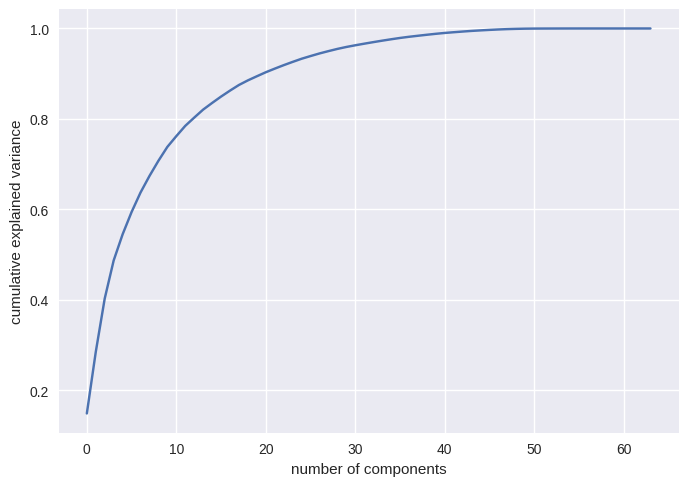

In [13]:
pca = PCA().fit(X)

plt.plot(np.cumsum(pca.explained_variance_ratio_))

plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

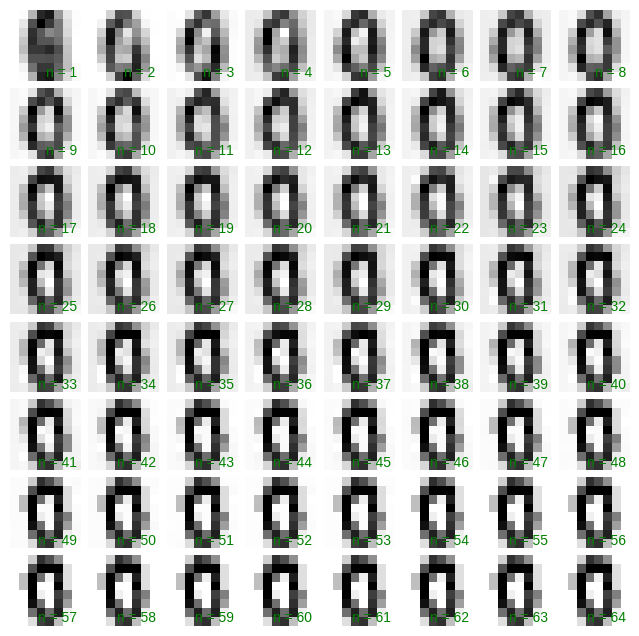

In [14]:
fig, axes = plt.subplots(8, 8, figsize=(8, 8))

fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, ax in enumerate(axes.flat):
    pca = PCA(i + 1).fit(X)
    im = pca.inverse_transform(pca.transform(X[20:21]))

    ax.imshow(im.reshape((8, 8)), cmap='binary')
    ax.text(0.95, 0.05, 'n = {0}'.format(i + 1),
            ha='right',
            transform=ax.transAxes,
            color='green')

    ax.set_xticks([])
    ax.set_yticks([])

In [15]:
from ipywidgets import interact

def plot_digits(n_components):

    fig = plt.figure(figsize=(8, 8))
    plt.subplot(1, 1, 1, frameon=False, xticks=[], yticks=[])

    nside = 10

    pca = PCA(n_components).fit(X)
    Xproj = pca.inverse_transform(pca.transform(X[:nside ** 2]))
    Xproj = np.reshape(Xproj, (nside, nside, 8, 8))

    total_var = pca.explained_variance_ratio_.sum()

    im = np.vstack([np.hstack([Xproj[i, j] for j in range(nside)])
                    for i in range(nside)])

    plt.imshow(im)
    plt.grid(False)

    plt.title(
        "n = {0}, variance = {1:.2f}".format(n_components, total_var),
        size=18
    )

    plt.clim(0, 16)


interact(plot_digits, n_components=[1, 64]);

interactive(children=(Dropdown(description='n_components', options=(1, 64), value=1), Output()), _dom_classes=…